# Zadanie 1

Wymiary obrazu: (720, 959, 3)
Wiadomość: Tajna wiadomość
Długość wiadomości w bitach: 136
Odkryta wiadomość: Tajna wiadomość


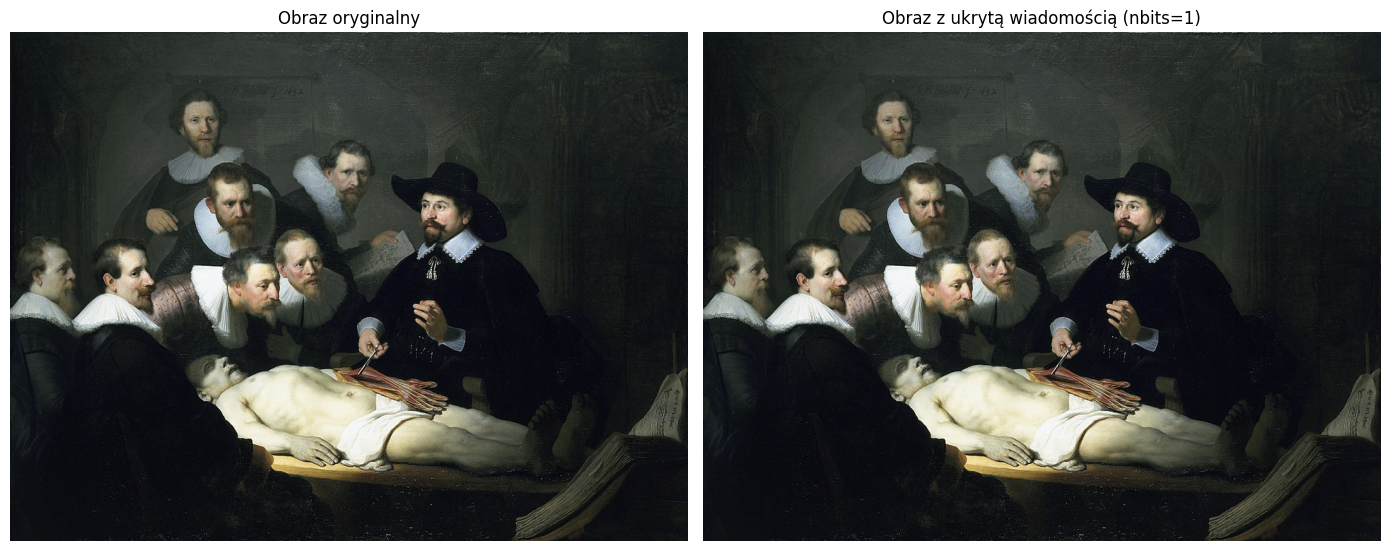

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import binascii
import cv2 as cv
import math

plt.rcParams["figure.figsize"] = (14, 6)


def encode_as_binary_array(msg):
    """Encode a message as a binary string."""
    msg = msg.encode("utf-8")
    msg = msg.hex()
    msg = [msg[i:i + 2] for i in range(0, len(msg), 2)]
    msg = ["{:08b}".format(int(el, base=16)) for el in msg]
    return "".join(msg)


def decode_from_binary_array(array):
    """Decode a binary string to utf8."""
    array = [array[i:i+8] for i in range(0, len(array), 8)]
    if len(array[-1]) != 8:
        array[-1] = array[-1] + "0" * (8 - len(array[-1]))
    array = ["{:02x}".format(int(el, 2)) for el in array]
    array = "".join(array)
    result = binascii.unhexlify(array)
    return result.decode("utf-8", errors="replace")


def load_image(path, pad=False):
    """Load an image. If pad is set then pad an image to multiple of 8 pixels."""
    image = cv.imread(path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    if pad:
        y_pad = 8 - (image.shape[0] % 8)
        x_pad = 8 - (image.shape[1] % 8)
        image = np.pad(
            image, ((0, y_pad), (0, x_pad), (0, 0)), mode='constant')
    return image


def save_image(path, image):
    """Save an image."""
    plt.imsave(path, image)


def clamp(n, minn, maxn):
    """Clamp the n value to be in range (minn, maxn)."""
    return max(min(maxn, n), minn)


def hide_message(image, message, nbits=1):
    """Hide a message in an image (LSB).
    
    nbits: number of least significant bits
    """
    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()
    if len(message) > len(image) * nbits:
        raise ValueError("Message is too long :(")
    
    chunks = [message[i:i + nbits] for i in range(0, len(message), nbits)]
    for i, chunk in enumerate(chunks):
        byte = "{:08b}".format(image[i])
        new_byte = byte[:-nbits] + chunk
        image[i] = int(new_byte, 2)
        
    return image.reshape(shape)


def reveal_message(image, nbits=1, length=0):
    """Reveal the hidden message.
    
    nbits: number of least significant bits
    length: length of the message in bits.
    """
    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()
    length_in_pixels = math.ceil(length/nbits)
    if len(image) < length_in_pixels or length_in_pixels <= 0:
        length_in_pixels = len(image)
    
    message = ""
    i = 0
    while i < length_in_pixels:
        byte = "{:08b}".format(image[i])
        message += byte[-nbits:]
        i += 1
        
    mod = length % -nbits
    if mod != 0:
        message = message[:mod]
    return message


secret_message = "Tajna wiadomość"

original_image = load_image("images/rembrandt.png")
print(f"Wymiary obrazu: {original_image.shape}")

binary_message = encode_as_binary_array(secret_message)
print(f"Wiadomość: {secret_message}")
print(f"Długość wiadomości w bitach: {len(binary_message)}")

nbits = 1
image_with_message = hide_message(original_image, binary_message, nbits)

save_image("images/moja_tajna_wiadomosc.png", image_with_message)
loaded_image = load_image("images/moja_tajna_wiadomosc.png")
revealed_binary = reveal_message(loaded_image, nbits=nbits, length=len(binary_message))
revealed_message = decode_from_binary_array(revealed_binary)
print(f"Odkryta wiadomość: {revealed_message}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(original_image)
axes[0].set_title("Obraz oryginalny")
axes[0].axis('off')

axes[1].imshow(image_with_message)
axes[1].set_title(f"Obraz z ukrytą wiadomością (nbits={nbits})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Zadanie 3.5

Wymiary obrazu: (720, 959, 3)
Całkowita liczba pikseli (z kanałami): 2071440
Wymagana długość wiadomości (bity): 1553580
Długość wiadomości w bitach: 168000
Procent zajętości dla nbits=1: 8.1%

--- Przetwarzanie nbits=1 ---
MSE dla nbits=1: 0.040680

--- Przetwarzanie nbits=2 ---
MSE dla nbits=2: 0.091172

--- Przetwarzanie nbits=3 ---
MSE dla nbits=3: 0.243135

--- Przetwarzanie nbits=4 ---
MSE dla nbits=4: 0.741254

--- Przetwarzanie nbits=5 ---
MSE dla nbits=5: 2.539518

--- Przetwarzanie nbits=6 ---
MSE dla nbits=6: 6.246278

--- Przetwarzanie nbits=7 ---
MSE dla nbits=7: 23.148440

--- Przetwarzanie nbits=8 ---
MSE dla nbits=8: 63.260007


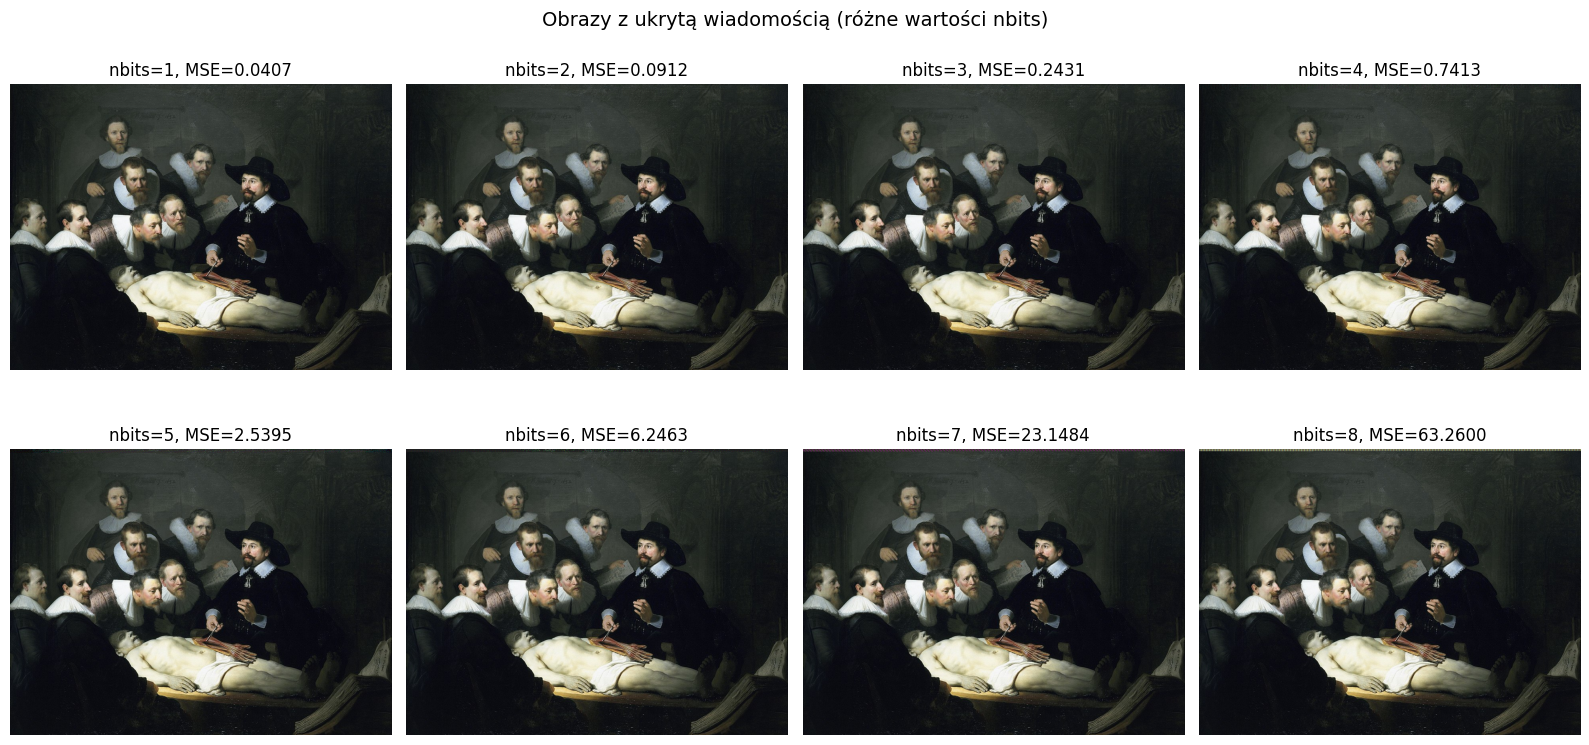

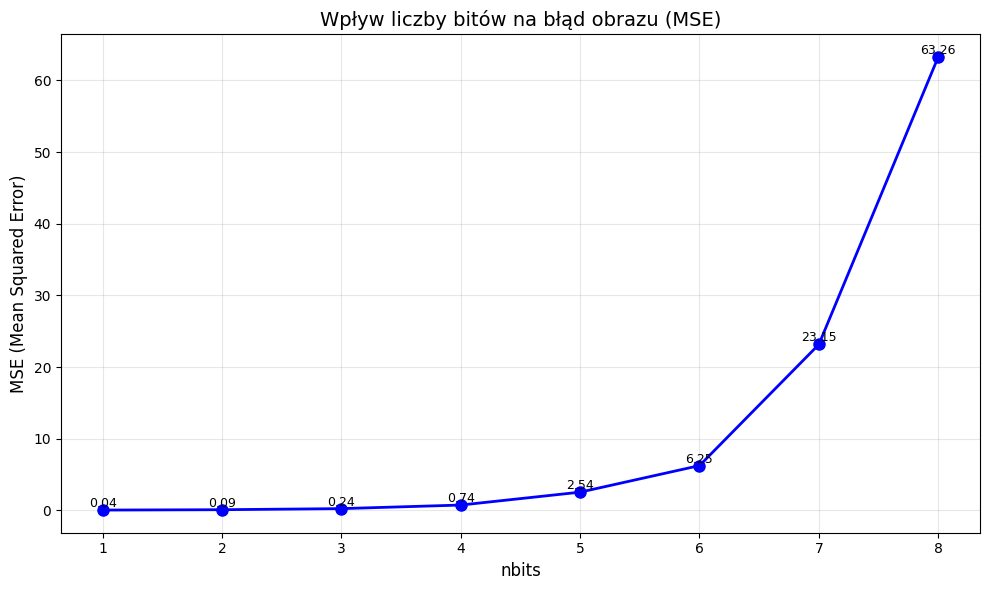

Tabela wyników MSE:
  nbits=1: MSE=0.040680
  nbits=2: MSE=0.091172
  nbits=3: MSE=0.243135
  nbits=4: MSE=0.741254
  nbits=5: MSE=2.539518
  nbits=6: MSE=6.246278
  nbits=7: MSE=23.148440
  nbits=8: MSE=63.260007


In [3]:
import numpy as np
from matplotlib import pyplot as plt

# Wczytanie obrazu
original_image = load_image("images/rembrandt.png")
print(f"Wymiary obrazu: {original_image.shape}")
total_pixels = original_image.shape[0] * original_image.shape[1] * original_image.shape[2]
print(f"Całkowita liczba pikseli (z kanałami): {total_pixels}")

# 75% obrazka = 0.75 * total_pixels bitów
required_bits = int(0.75 * total_pixels)
print(f"Wymagana długość wiadomości (bity): {required_bits}")

base_text = "Sekretna wiadomość " * 1000
secret_message = base_text[:int(required_bits / 8)]
binary_message = encode_as_binary_array(secret_message)
print(f"Długość wiadomości w bitach: {len(binary_message)}")
print(f"Procent zajętości dla nbits=1: {(len(binary_message) / total_pixels * 100):.1f}%")

mse_results = []
nbits_values = []


def calculate_mse(original, modified):
    """Oblicz Mean Squared Error między dwoma obrazami."""
    mse = np.mean((original.astype(float) - modified.astype(float)) ** 2)
    return mse

# Generowanie obrazków dla każdej wartości nbits
fig_preview, axes_preview = plt.subplots(2, 4, figsize=(16, 8))
axes_preview = axes_preview.flatten()

for nbits in range(1, 9):
    print(f"\n--- Przetwarzanie nbits={nbits} ---")
    
    # Ukrycie wiadomości
    image_with_message = hide_message(original_image, binary_message, nbits)
    
    # Obliczenie MSE
    mse = calculate_mse(original_image, image_with_message)
    mse_results.append(mse)
    nbits_values.append(nbits)
    print(f"MSE dla nbits={nbits}: {mse:.6f}")
    
    # Zapisanie obrazu
    save_image(f"images/hidden_message_nbits_{nbits}.png", image_with_message)
    
    # Weryfikacja - odczyt wiadomości
    revealed_binary = reveal_message(image_with_message, nbits=nbits, length=len(binary_message))
    revealed_message = decode_from_binary_array(revealed_binary)
    
    # Wyświetlenie w grid
    axes_preview[nbits-1].imshow(image_with_message)
    axes_preview[nbits-1].set_title(f"nbits={nbits}, MSE={mse:.4f}")
    axes_preview[nbits-1].axis('off')

plt.tight_layout()
plt.suptitle("Obrazy z ukrytą wiadomością (różne wartości nbits)", fontsize=14, y=1.00)
plt.show()

# Wykreślenie MSE vs nbits
plt.figure(figsize=(10, 6))
plt.plot(nbits_values, mse_results, 'bo-', linewidth=2, markersize=8)
plt.xlabel('nbits', fontsize=12)
plt.ylabel('MSE (Mean Squared Error)', fontsize=12)
plt.title('Wpływ liczby bitów na błąd obrazu (MSE)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(nbits_values)

# Dodanie wartości na wykresie
for nbits, mse in zip(nbits_values, mse_results):
    plt.text(nbits, mse, f'{mse:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Tabela wyników MSE:")
for nbits, mse in zip(nbits_values, mse_results):
    print(f"  nbits={nbits}: MSE={mse:.6f}")


# Zadanie 4.0

Wymiary obrazu: (720, 959, 3)
Całkowita liczba pikseli: 2071440

Wiadomość 1: 'Pierwsza wiadomość' (160 bitów)
Wiadomość 2: 'Druga wiadomość ukryta dalej' (240 bitów)
Wiadomość 3: 'Trzecia wiadomość na końcu' (232 bitów)

Ukrywanie na pozycjach: 0, 160, 400

Odczyt wiadomości z obrazu:
Wiadomość 1 (spos=0): 'Pierwsza wiadomość' ✓
Wiadomość 2 (spos=160): 'Druga wiadomość ukryta dalej' ✓
Wiadomość 3 (spos=400): 'Trzecia wiadomość na końcu' ✓


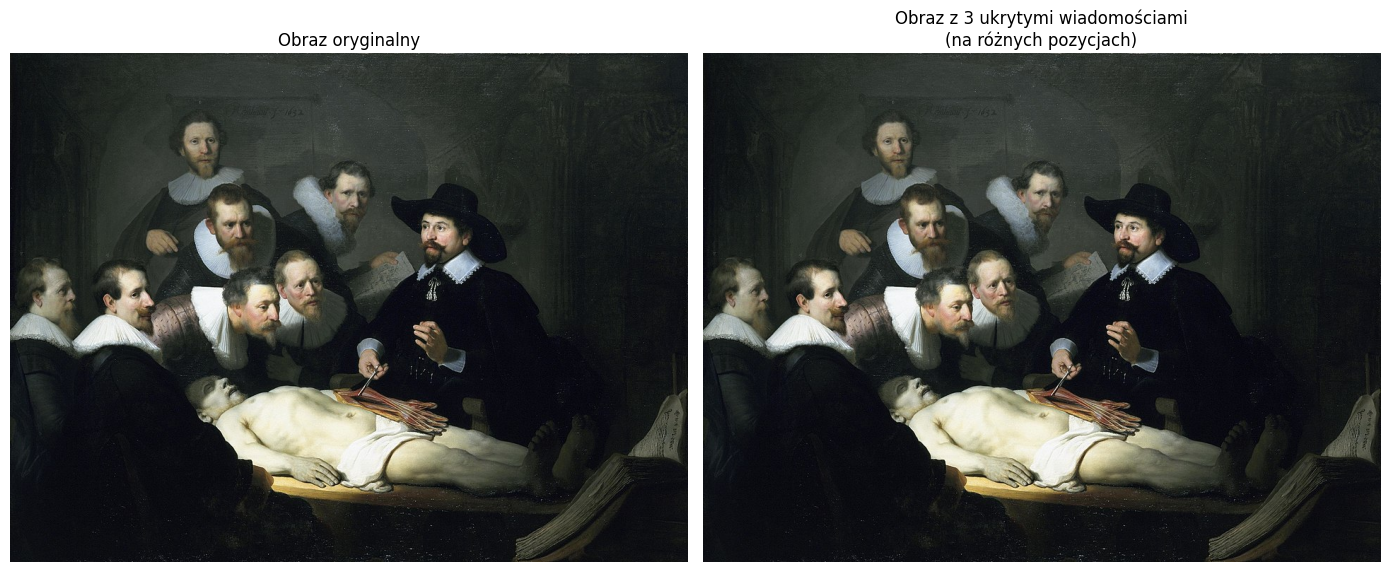

In [5]:
def hide_message_v2(image, message, nbits=1, spos=0):
    """Hide a message in an image (LSB) starting from position spos.
    
    Args:
        image: macierz zawierająca obraz
        message: wiadomość jako ciąg 0 i 1
        nbits: liczba najmłodszych bitów
        spos: pozycja początkowa w spłaszczonej tablicy obrazu
    """
    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()
    
    # Sprawdzenie czy wiadomość mieści się w obrazie
    available_space = (len(image) - spos) * nbits
    if len(message) > available_space:
        raise ValueError(f"Wiadomość jest za długa. Dostępne miejsce: {available_space} bitów, wymagane: {len(message)} bitów")
    
    chunks = [message[i:i + nbits] for i in range(0, len(message), nbits)]
    for i, chunk in enumerate(chunks):
        pos = spos + i
        byte = "{:08b}".format(image[pos])
        new_byte = byte[:-nbits] + chunk
        image[pos] = int(new_byte, 2)
        
    return image.reshape(shape)


def reveal_message_v2(image, nbits=1, length=0, spos=0):
    """Reveal the hidden message starting from position spos.
    
    Args:
        image: macierz zawierająca obraz
        nbits: liczba najmłodszych bitów
        length: długość wiadomości w bitach (0 = wszystkie dostępne bity)
        spos: pozycja początkowa w spłaszczonej tablicy obrazu
    """
    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()
    
    # Sprawdzenie dostępnego miejsca
    available_pixels = len(image) - spos
    if available_pixels <= 0:
        raise ValueError(f"Pozycja początkowa {spos} jest poza granicami obrazu (rozmiar: {len(image)})")
    
    # Jeśli nie podano długości, użyj wszystkich dostępnych bitów
    if length == 0:
        length_in_pixels = available_pixels
    else:
        length_in_pixels = math.ceil(length / nbits)
        if length_in_pixels > available_pixels:
            raise ValueError(f"Żądana długość wiadomości {length} bitów przekracza dostępne miejsce")
    
    message = ""
    for i in range(length_in_pixels):
        pos = spos + i
        if pos >= len(image):
            break
        byte = "{:08b}".format(image[pos])
        message += byte[-nbits:]
        
        if length > 0 and len(message) >= length:
            message = message[:length]
            break
    
    return message


# Wczytanie obrazu
test_image = load_image("images/rembrandt.png")
print(f"Wymiary obrazu: {test_image.shape}")
total_pixels = test_image.shape[0] * test_image.shape[1] * test_image.shape[2]
print(f"Całkowita liczba pikseli: {total_pixels}\n")

# Generowanie testowych wiadomości
msg1 = "Pierwsza wiadomość"
msg2 = "Druga wiadomość ukryta dalej"
msg3 = "Trzecia wiadomość na końcu"

binary_msg1 = encode_as_binary_array(msg1)
binary_msg2 = encode_as_binary_array(msg2)
binary_msg3 = encode_as_binary_array(msg3)

print(f"Wiadomość 1: '{msg1}' ({len(binary_msg1)} bitów)")
print(f"Wiadomość 2: '{msg2}' ({len(binary_msg2)} bitów)")
print(f"Wiadomość 3: '{msg3}' ({len(binary_msg3)} bitów)\n")

# Ukrycie wszystkich trzech wiadomości w jednym obrazie
result_image = np.copy(test_image)

# Pozycje początkowe
spos1 = 0
spos2 = math.ceil(len(binary_msg1) / 1)
spos3 = spos2 + math.ceil(len(binary_msg2) / 1)

print(f"Ukrywanie na pozycjach: {spos1}, {spos2}, {spos3}")

result_image = hide_message_v2(result_image, binary_msg1, nbits=1, spos=spos1)
result_image = hide_message_v2(result_image, binary_msg2, nbits=1, spos=spos2)
result_image = hide_message_v2(result_image, binary_msg3, nbits=1, spos=spos3)

# Zapisanie obrazu
save_image("images/multiple_messages_hidden.png", result_image)

# Odczyt wiadomości
print("\nOdczyt wiadomości z obrazu:")
revealed_msg1 = decode_from_binary_array(
    reveal_message_v2(result_image, nbits=1, length=len(binary_msg1), spos=spos1))
revealed_msg2 = decode_from_binary_array(
    reveal_message_v2(result_image, nbits=1, length=len(binary_msg2), spos=spos2))
revealed_msg3 = decode_from_binary_array(
    reveal_message_v2(result_image, nbits=1, length=len(binary_msg3), spos=spos3))

print(f"Wiadomość 1 (spos={spos1}): '{revealed_msg1}' ✓" if revealed_msg1 == msg1 else f"Wiadomość 1 (spos={spos1}): '{revealed_msg1}' ✗")
print(f"Wiadomość 2 (spos={spos2}): '{revealed_msg2}' ✓" if revealed_msg2 == msg2 else f"Wiadomość 2 (spos={spos2}): '{revealed_msg2}' ✗")
print(f"Wiadomość 3 (spos={spos3}): '{revealed_msg3}' ✓" if revealed_msg3 == msg3 else f"Wiadomość 3 (spos={spos3}): '{revealed_msg3}' ✗")

# Wyświetlenie porównania
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(test_image)
axes[0].set_title("Obraz oryginalny")
axes[0].axis('off')

axes[1].imshow(result_image)
axes[1].set_title("Obraz z 3 ukrytymi wiadomościami\n(na różnych pozycjach)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


# Zadanie 4.5

Wymiary obrazu-nośnika: (720, 959, 3)
Całkowita liczba pikseli: 2071440

Długość ukrytego obrazka: 191568 bitów (23946 bajtów)
Procent zajętości obrazu-nośnika: 100.0000%

Obraz z ukrytym obrazkiem zapisany: images/carrier_with_hidden_image.png

Wyodrębnianie ukrytego obrazka...
Wyodrębniony plik zapisany: images/extracted_spanish.jpg
Wyodrębnione dane: 23946 bajtów

Porównanie oryginalnego i wyodrębnionego obrazka:
Wymiary oryginalny: (316, 460, 3)
Wymiary wyodrębniony: (316, 460, 3)
MSE: 0.000000


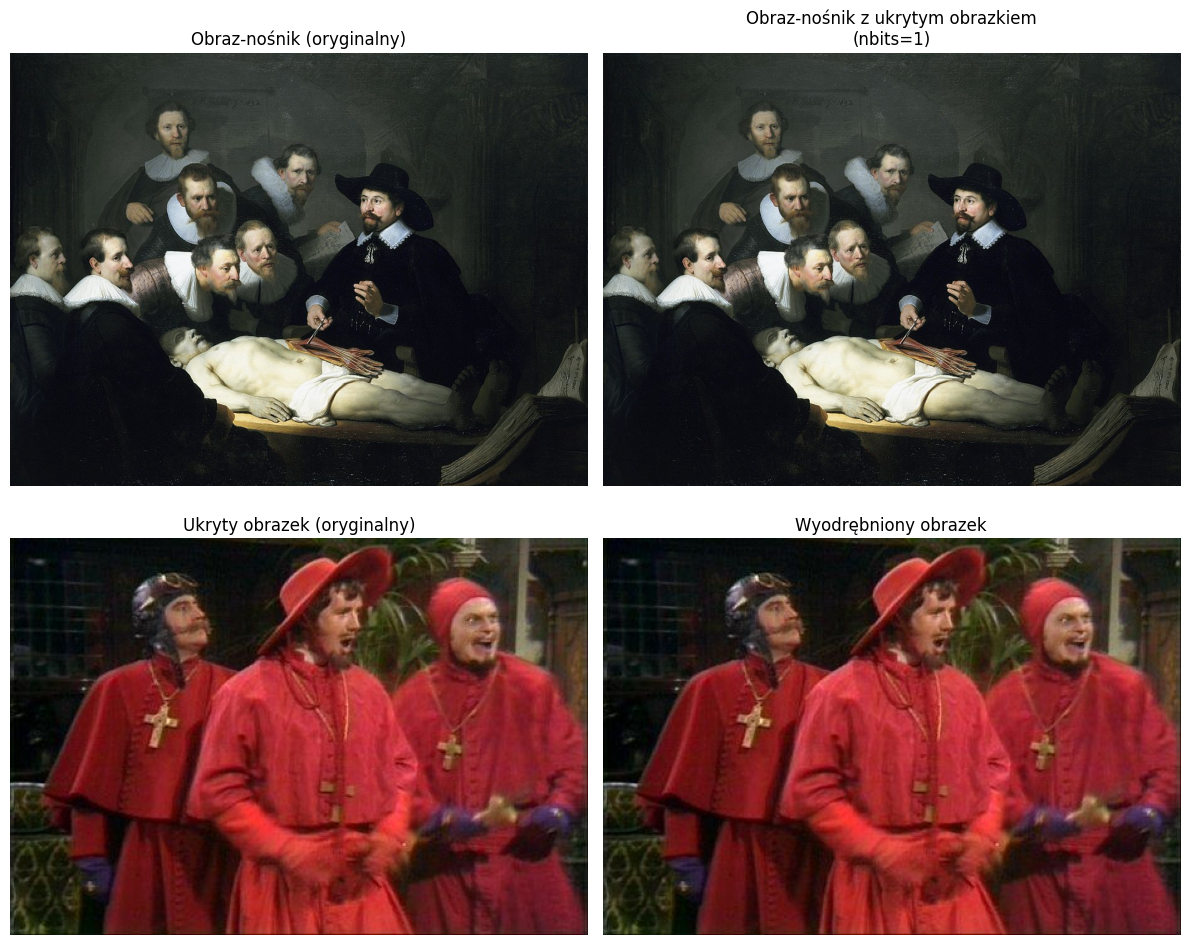

In [9]:
def hide_image(image, secret_image_path, nbits=1):
    """Ukryj obrazek (plik binarny) w obrazie."""
    with open(secret_image_path, "rb") as file:
        secret_img = file.read()
        
    secret_img_hex = secret_img.hex()
    secret_img_bytes = [secret_img_hex[i:i + 2] for i in range(0, len(secret_img_hex), 2)]
    secret_img_binary = ["{:08b}".format(int(el, base=16)) for el in secret_img_bytes]
    secret_img_binary_str = "".join(secret_img_binary)
    
    return hide_message(image, secret_img_binary_str, nbits), len(secret_img_binary_str), len(secret_img)


def extract_image(image, length, nbits=1, output_path=None):
    """Wyodrębnij ukryty obrazek z obrazu i opcjonalnie zapisz go do pliku.
    
    Args:
        image: obrazek zawierający ukrytą wiadomość (obraz)
        length: długość ukrytej wiadomości w bitach
        nbits: liczba najmłodszych bitów
        output_path: ścieżka do zapisania wyodrębnionego obrazka (opcjonalnie)
    
    Returns:
        Zapisany plik binarny jako bajty
    """
    # Ekstrahowanie bitów z obrazu
    revealed_binary = reveal_message(image, nbits=nbits, length=length)
    
    # Konwersja ciągu bitów na bajty
    # Pad binary string do wielokrotności 8 jeśli to konieczne
    if len(revealed_binary) % 8 != 0:
        revealed_binary += "0" * (8 - len(revealed_binary) % 8)
    
    # Konwersja na bajty
    bytes_list = []
    for i in range(0, len(revealed_binary), 8):
        byte_str = revealed_binary[i:i+8]
        byte_val = int(byte_str, 2)
        bytes_list.append(byte_val)
    
    binary_data = bytes(bytes_list)
    
    # Zapisanie do pliku jeśli podana ścieżka
    if output_path:
        with open(output_path, "wb") as f:
            f.write(binary_data)
        print(f"Wyodrębniony plik zapisany: {output_path}")
    
    return binary_data

# Załadowanie obrazu-nośnika
carrier_image = load_image("images/rembrandt.png")
print(f"Wymiary obrazu-nośnika: {carrier_image.shape}")
print(f"Całkowita liczba pikseli: {carrier_image.shape[0] * carrier_image.shape[1] * carrier_image.shape[2]}\n")

# Ukrycie obrazka w obrazie
nbits = 1

image_with_secret, length_of_secret, total_pixels = hide_image(
    carrier_image, "images/spanish.jpg", nbits)

print(f"Długość ukrytego obrazka: {length_of_secret} bitów ({length_of_secret / 8:.0f} bajtów)")
print(f"Procent zajętości obrazu-nośnika: {(length_of_secret / (total_pixels * 8) * 100):.4f}%\n")

# Zapisanie obrazu z ukrytym obrazkiem
save_image("images/carrier_with_hidden_image.png", image_with_secret)
print("Obraz z ukrytym obrazkiem zapisany: images/carrier_with_hidden_image.png\n")

# Wyodrębnienie ukrytego obrazka
print("Wyodrębnianie ukrytego obrazka...")
extracted_image_data = extract_image(
    image_with_secret, 
    length=length_of_secret, 
    nbits=nbits, 
    output_path="images/extracted_spanish.jpg"
)

print(f"Wyodrębnione dane: {len(extracted_image_data)} bajtów\n")

# Załadowanie obu wersji obrazka (oryginalny i wyodrębniony) do porównania
original_secret = load_image("images/spanish.jpg")
extracted_secret = load_image("images/extracted_spanish.jpg")

# Porównanie
print("Porównanie oryginalnego i wyodrębnionego obrazka:")
print(f"Wymiary oryginalny: {original_secret.shape}")
print(f"Wymiary wyodrębniony: {extracted_secret.shape}")

# Obliczenie MSE jeśli wymiary się zgadzają
if original_secret.shape == extracted_secret.shape:
    mse = np.mean((original_secret.astype(float) - extracted_secret.astype(float)) ** 2)
    print(f"MSE: {mse:.6f}")
else:
    print("Wymiary się nie zgadzają - nie można obliczyć MSE")

# Wyświetlenie wszystkich obrazów
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(carrier_image)
axes[0, 0].set_title("Obraz-nośnik (oryginalny)")
axes[0, 0].axis('off')

axes[0, 1].imshow(image_with_secret)
axes[0, 1].set_title(f"Obraz-nośnik z ukrytym obrazkiem\n(nbits={nbits})")
axes[0, 1].axis('off')

axes[1, 0].imshow(original_secret)
axes[1, 0].set_title("Ukryty obrazek (oryginalny)")
axes[1, 0].axis('off')

axes[1, 1].imshow(extracted_secret)
axes[1, 1].set_title("Wyodrębniony obrazek")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


# Zadanie 5

In [ ]:
#
# tu umieść kod
#